# Regional and Local Sea Level Change   
 
```{glue:figure} trend_fig
:scale: 50%
:align: right
```

Since the start of continuous satellite measurements of global sea level in 1993, the absolute mean sea level in the vicinity of the {glue:text}`station` tide gauge has risen by {glue:text}`delta_cm_altimetry:.2f` cm ({glue:text}`delta_in_altimetry:.2f` in). This compares to a relative value of {glue:text}`delta_cm_tide_gauge:.2f` cm ({glue:text}`delta_in_tide_gauge:.2f` in) measured by the tide gauge over this same time period.   These values correspond to satellite-derived and station-derived rates of {glue:text}`trend_mmyr_altimetry:.2f` mm ({glue:text}`trend_inyr_altimetry:.2f` in) per year and {glue:text}`trend_mmyr_tide_gauge:.2f` mm ({glue:text}`trend_inyr_tide_gauge:.2f` in) per year, respectively. Differences in the rates of absolute (satellite-measured) and relative (tide gauge measured) sea level rise is largely attributable to vertical land motion. The sea level near {glue:text}`country` is rising faster than the global average, with satellite data showing a global mean sea level (GMSL) rise of  4.4 mm (0.17 in) per year ([Willis et al., 2023](https://zenodo.org/records/7702315)).

In this notebook, we'll be creating a [table](SL_magnitude_results), a [map](fig-mag), and a time series [plot](trend_fig) of absolute and regional sea level change at the {glue:text}`station`, {glue:text}`country` tide gauge station from 1993-2022. Absolute sea level, typically measured by satellite altimetry, refers to the height of the sea surface relative to a reference ellipsoid. Here, we'll use the global ocean gridded L4 Sea Level Anomalies (SLA) available from Copernicus, which is the sea surface height (SSH) minus the mean sea surface (MSS), where the MSS is the temporal mean of SSH over a given period. Relative sea level is measured by a tide gauge, and is the sea level relative to land at that location. Differences between the two measurements can arise from vertical land motion, regional oceanographic conditions like currents, and changes to the gravitational field (affecting the geoid). 

Download Files:
[Map](../output/SL_magnitude_map.png) |
[Time Series Plot](../output/SL_magnitude_timeseries.png) |
[Table](../output/SL_magnitude_results.csv)


## Setup

First, we need to import all the necessary libraries.


In [1]:
# import necessary libraries
import numpy as np
import xarray as xr
import datetime as dt
from pathlib import Path
import pandas as pd
import os
import os.path as op
import sys

# data retrieval libraries
import requests

# plotting and notebook output
import matplotlib.pyplot as plt
from myst_nb import glue  # used for figure numbering when exporting to LaTeX

sys.path.append("../../functions")
from data_downloaders import download_oni_index, download_uhslc_data
import importlib
import sea_level as sea_level_mod
importlib.reload(sea_level_mod)
from sea_level import (
    process_trend_with_nan,
    build_enso_summary_table,
    build_sl_magnitude_results,
    save_table_to_csv,
    save_dict_json,
    select_uhslc_station,
    load_site_config,
    build_output_filename,
    build_site_tag,
)
from sea_level_plotting import (
    plot_station_vs_grid_map,
    plot_altimetry_scatter,
    plot_map_base,
    plot_magnitude_map_background,
    plot_zebra_frame,
    plot_altimetry_trend_timeseries,
    plot_tide_gauge_scatter,
    plot_tide_gauge_trend_timeseries,
    plot_magnitude_map,
    plot_combined_trends,
    plot_enso_scatter,
)


Next, we'll establish our directory for saving and reading data, and our output files.


In [2]:
data_base_dir =  Path('../../data')
path_figs = "../../matrix_cc/figures"
data_dir = Path(data_base_dir,'sea_level')
output_dir = data_base_dir 

# Create the output directory if it does not exist
output_dir.mkdir(exist_ok=True)
data_dir.mkdir(exist_ok=True)

# Also let's just make our figure sizes the same:
plt.rcParams['figure.figsize'] = [10, 4]  # Set a default figure size for the notebook


In [3]:
# Site-specific configuration loaded from shared site setup
site_config_path = Path('../../data/sites/palau.json')
site_cfg = load_site_config(site_config_path)

site_name = site_cfg.get('site_name', 'Site')
site_lon = float(site_cfg.get('site_lon'))
site_lat = float(site_cfg.get('site_lat'))
station_country_filter = site_cfg.get('station_country_filter')
selected_uhslc_id = site_cfg.get('selected_uhslc_id')
selected_station_name = site_cfg.get('selected_station_name')

site_eez_shapefile = Path(site_cfg.get('site_eez_shapefile'))

start_date = pd.to_datetime(site_cfg.get('start_date')).to_pydatetime()
end_date = pd.to_datetime(site_cfg.get('end_date')).to_pydatetime()

cmems_bbox_override = site_cfg.get('cmems_bbox_override')
cmems_start_datetime = site_cfg.get('cmems_start_datetime', '1993-01-01T00:00:00')
cmems_end_datetime = site_cfg.get('cmems_end_datetime', '2025-04-30T23:59:59')

site_output_dir = Path('../../outputs') / build_site_tag(site_name, site_lon, site_lat)
site_output_dir.mkdir(parents=True, exist_ok=True)


## Load Site Data Sources

We are interested in getting tide gauge and alitmetry data for {glue:text}`country` (and its EEZ) for 1993 through 2022.
Let's first establish where the tide gauge is by looking at the tide gauge dataset.

### Retrieve the location of the {glue:text}`station`, {glue:text}`country` tide gauge


In [4]:
site_cfg = load_site_config(site_config_path)


In [5]:
site_cfg = load_site_config(site_config_path)
site_name = site_cfg.get('site_name', 'Site')
site_lon = float(site_cfg.get('site_lon'))
site_lat = float(site_cfg.get('site_lat'))
uhslc_id = int(site_cfg.get('selected_uhslc_id'))
station = site_cfg.get('station', site_cfg.get('selected_station_name', 'Station'))
country = site_cfg.get('country', site_cfg.get('station_country_filter', 'Country'))
lat = float(site_cfg.get('station_lat', site_lat))
lon = float(site_cfg.get('station_lon', site_lon))


Next, we use the period of record defined in the site configuration cell.


In [6]:
# Use configured period of record and save as strings for plotting
start_date_str = start_date.strftime('%Y-%m-%d')
end_date_str = end_date.strftime('%Y-%m-%d')

glue("site_name", site_name, display=False)
glue("station", station, display=False)
glue("country", country, display=False)
glue("startDateTime", start_date_str, display=False)
glue("endDateTime", end_date_str, display=False)


### Retrieve the EEZ boundary for the configured site

Next we'll define the area we want to look at using the EEZ boundary. This can be obtained from the [Pacific Environmental Data Portal](https://pacific-data.sprep.org). For now it's in the data directory.


In [7]:
# Retrieve EEZ for the configured site
import geopandas as gpd

# Resolve shapefile from notebook location
notebook_dir = Path.cwd()
eez_path = (notebook_dir / site_eez_shapefile).resolve()

site_shp = gpd.read_file(eez_path)
geometry = site_shp['geometry']
site_eez = np.array(geometry.iloc[0].exterior.coords.xy).T

# Keep legacy variable name used later in notebook
site_eez = site_eez

# Infer CMEMS bbox from EEZ unless explicitly overridden
if cmems_bbox_override is None:
    min_lon = float(np.min(site_eez[:, 0]))
    max_lon = float(np.max(site_eez[:, 0]))
    min_lat = float(np.min(site_eez[:, 1]))
    max_lat = float(np.max(site_eez[:, 1]))
else:
    min_lon, max_lon, min_lat, max_lat = cmems_bbox_override


### Retrieve altimetry data 


We are using the global ocean gridded L4 Sea Surface Heights and Derived Variables from Copernicus, available at https://doi.org/10.48670/moi-00148. 

CMEMS data is prepared in `0_site_setup.ipynb` and referenced from the saved site configuration. If missing, rerun setup before running this notebook.

````{margin}
```{note}
You will need a username and password to access the CMEMS (Copernicus Marine Service) data if this is the first time running the client. To register for data access (free), visit https://data.marine.copernicus.eu/register.  
```
````

```{admonition} Large data download!
:class: warning
CMEMS data is prepared during `0_site_setup.ipynb`. If this cell fails, run the setup notebook first so the required dataset exists in the site data directory.
```


In [8]:
cmems_filename = site_cfg.get('cmems_filename')
cmems_path = Path(site_cfg.get('cmems_path', data_dir / (cmems_filename or '')))
if not cmems_path.exists():
    raise FileNotFoundError(
        f"CMEMS file not found: {cmems_path}. Run 0_site_setup.ipynb first to prepare site data."
    )

print(f'Using prepared CMEMS data: {cmems_path.name}')

ds = xr.open_dataset(cmems_path, engine="h5netcdf", chunks={"latitude": 40, "longitude": 40})

# Slice to configured period of record.
ds = ds.sel(time=slice(start_date, end_date))
ds


Using prepared CMEMS data: cmems_L4_SSH_0.125deg_1993_2025.nc


<xarray.Dataset> Size: 3GB
Dimensions:    (time: 10957, latitude: 120, longitude: 120)
Coordinates:
  * latitude   (latitude) float32 480B 0.0625 0.1875 0.3125 ... 14.81 14.94
  * longitude  (longitude) float32 480B 125.1 125.2 125.3 ... 139.7 139.8 139.9
  * time       (time) datetime64[ns] 88kB 1993-01-01 1993-01-02 ... 2022-12-31
Data variables:
    adt        (time, latitude, longitude) float64 1GB dask.array<chunksize=(10957, 40, 40), meta=np.ndarray>
    sla        (time, latitude, longitude) float64 1GB dask.array<chunksize=(10957, 40, 40), meta=np.ndarray>
Attributes:
    references:                http://marine.copernicus.eu
    Conventions:               CF-1.6
    comment:                   Sea Surface Height measured by Altimetry and d...
    title:                     DT merged all satellites Global Ocean Gridded ...
    source:                    Altimetry measurements
    history:                   2024-10-23 12:55:06Z: Creation
    institution:               CLS, CNES
    contact:                   servicedesk.cmems@mercator-ocean.eu
    copernicusmarine_version:  2.0.0a4

### Retrieve Tide Gauge Data


Next we'll retrieve tide gauge data from the UHSLC (University of Hawaii Sea Level Center) fast-delivery dataset {cite:t}``. The fast-delivery data are released within 1-2 months of data collection and are subject only to basic quality control. 

````{margin}
```{note}
What about research quality data (RQD)? 
RQD undergo thorough and time-consuming QC, and are usually released 1-2 years after data is received. 
```
````

The code block below downloads the data file if it doesn't already exist in the specified data directory.
The tide gauge data is then opened using xarray and the station name is extracted.


In [9]:
# Download tide gauge data for configured UHSLC station
rsl = download_uhslc_data(data_dir, uhslc_id, 'daily')
station_name = rsl.station_name.values[0]
rsl


<xarray.Dataset> Size: 249kB
Dimensions:               (record_id: 1, time: 20771)
Coordinates:
  * time                  (time) datetime64[ns] 166kB 1969-05-19T12:00:00 ......
  * record_id             (record_id) int64 8B 7
Data variables:
    sea_level             (record_id, time) float32 83kB ...
    lat                   (record_id) float32 4B ...
    lon                   (record_id) float32 4B ...
    station_name          (record_id) <U7 28B 'Malakal'
    station_country       (record_id) <U5 20B 'Palau'
    station_country_code  (record_id) float32 4B ...
    uhslc_id              (record_id) int16 2B ...
    gloss_id              (record_id) float32 4B ...
    ssc_id                (record_id) |S4 4B ...
    last_rq_date          (record_id) datetime64[ns] 8B ...
Attributes:
    title:                  UHSLC Fast Delivery Tide Gauge Data (daily)
    ncei_template_version:  NCEI_NetCDF_TimeSeries_Orthogonal_Template_v2.0
    featureType:            timeSeries
    Conventions:            CF-1.6, ACDD-1.3
    date_created:           2026-05-05T14:26:56Z
    publisher_name:         University of Hawaii Sea Level Center (UHSLC)
    publisher_email:        philiprt@hawaii.edu, markm@soest.hawaii.edu
    publisher_url:          http://uhslc.soest.hawaii.edu
    summary:                The UHSLC assembles and distributes the Fast Deli...
    processing_level:       Fast Delivery (FD) data undergo a level 1 quality...
    acknowledgment:         The UHSLC Fast Delivery database is supported by ...

## Process the data


 Now we'll convert tide gauge data into a daily record for the POR in units of meters to match the CMEMS data. 
 
 The next code block:
 - extracts tide gauge data for the period 1993-2022
 - converts it to meters
 - removes any NaN values
 - resamples the data to daily mean
 - and normalizes it relative to the 1993-2012 epoch. 
 
 The resulting data is stored in the variable 'rsl_daily' with units in meters.


In [10]:
# Extract the data for the period of record (POR)
tide_gauge_data_POR = rsl['sea_level'].sel(time=slice(start_date, end_date))

# Convert to meters and drop any NaN values
tide_gauge_data_meters = tide_gauge_data_POR / 1000  # Convert from mm to meters
tide_gauge_data_clean = tide_gauge_data_meters.dropna(dim='time')

# Get the mean relative to the 1993-2012 epoch
epoch_start, epoch_end = '1993-01-01', '2011-12-31'
epoch_daily_avg = tide_gauge_data_clean.sel(time=slice(epoch_start, epoch_end))
epoch_daily_mean = epoch_daily_avg.mean()

# Get the mean relative to the 1983-2001 (NTDE) epoch
epochNTDE_start, epochNTDE_end = '1983-01-01', '2001-12-31'
epoch_daily_avg = tide_gauge_data_clean.sel(time=slice(epochNTDE_start, epochNTDE_end))
epochNTDE_daily_mean = epoch_daily_avg.mean()

# Subtract the epoch NTDE daily mean to put everything in the MSL (NTDE) reference frame
rsl_daily = tide_gauge_data_clean - epochNTDE_daily_mean

# Set the attributes of the rsl_daily data
rsl_daily.attrs = tide_gauge_data_POR.attrs
rsl_daily.attrs['units'] = 'm'


# Remove any singleton dimensions
rsl_daily = rsl_daily.squeeze()

rsl_daily


<xarray.DataArray 'sea_level' (time: 10818)> Size: 43kB
array([-0.11846316, -0.12346315, -0.14646316, ...,  0.0945369 ,
        0.08153689,  0.08553684], shape=(10818,), dtype=float32)
Coordinates:
  * time       (time) datetime64[ns] 87kB 1993-01-01T12:00:00 ... 2022-12-30T...
    record_id  int64 8B 7
Attributes:
    long_name:  relative sea level
    units:      m
    source:     in situ tide gauge water level observations
    platform:   station_name, station_country, station_country_code, uhslc_id...

Run a quick check to see if the Ab SL from CMEMS is in fact zeroed about the 1993-2012 epoch. Curse the details.


In [11]:
# Normalize tide gauge data to CMEMS 1993-2012 epoch
epoch_daily_mean_cmems = ds['sla'].sel(
    time=slice(epoch_start, epoch_end)
).sel(
    longitude=lon, latitude=lat, method='nearest'
).mean(dim='time')

formatted_mean = format(epoch_daily_mean_cmems.values, ".2f")

# Print the mean with a note to re-check source data
print(
    f'The mean for the [{epoch_start},{epoch_end}] epoch of the SLA is {formatted_mean} m. '
)

# adjust altimetry anomalies to be relative to MSL (NTDE) reference frame
ds['sla'] = ds['sla'] -epoch_daily_mean_cmems+ epoch_daily_mean - epochNTDE_daily_mean


The mean for the [1993-01-01,2011-12-31] epoch of the SLA is 0.02 m. 


### Clip
Next we'll clip the Altimetry Data Set to the area/grid of interest. For now, we'll focus only on the grid cell nearest to the {glue:text}`station` tide gauge.

````{margin}
```{note}
There are a few options for tide gauge comparison:
1) Nearest neighbor
2) Highest correlated nearest neighbor
3) Average of n-nearest neighbors, etc

They all end up about the same for the Pacific Islands, so in this example we'll be choosing nearest neighbor.
```
````


In [12]:
sla = ds['sla'].sel(time=slice(start_date, end_date))
time_cmems = pd.to_datetime(sla['time'].values)

# Extract data for the nearest point to the tide gauge location
sla_nearest = sla.sel(longitude=lon, latitude=lat, method='nearest')

sla_nearest_lat = sla_nearest['latitude'].values
sla_nearest_lon = sla_nearest['longitude'].values

# Format lat lon strings to have decimal symbol and N/S and E/W
lat_str = f'{np.abs(sla_nearest_lat):.3f}\u00B0{"N" if sla_nearest_lat > 0 else "S"}'
lon_str = f'{np.abs(sla_nearest_lon):.3f}\u00B0{"E" if sla_nearest_lon > 0 else "W"}'

print(f'The closest altimetry grid point is {lat_str}, {lon_str}')
sla_nearest


The closest altimetry grid point is 7.312°N, 134.438°E


<xarray.DataArray 'sla' (time: 10957)> Size: 88kB
dask.array<getitem, shape=(10957,), dtype=float64, chunksize=(10957,), chunktype=numpy.ndarray>
Coordinates:
    latitude   float32 4B 7.312
    longitude  float32 4B 134.4
  * time       (time) datetime64[ns] 88kB 1993-01-01 1993-01-02 ... 2022-12-31

```{margin}
It should be noted that the coordinates from https://ccar.colorado.edu/altimetry/ for the altimetry product are: Lat: 7.2500°N, Lon: 134.4167°E, using https://podaac.jpl.nasa.gov/dataset/SEA_SURFACE_HEIGHT_ALT_GRIDS_L4_2SATS_5DAY_6THDEG_V_JPL1812 as their data source. This data is gridded at 1/6th of a degree as supposed to 1/8th of a degree in the source we are using.
```

Let's make a map to determine exactly where these points are in space using the shared plotting utilities.


In [13]:
# Plot helper functions were moved to ../../functions/sea_level.py.


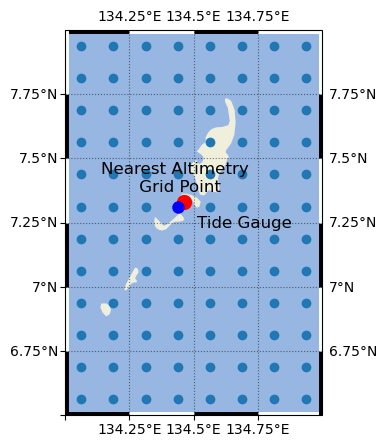

In [14]:
# Station and nearest-altimetry-location map
fig, ax = plot_station_vs_grid_map(
    lon=lon,
    lat=lat,
    sla_nearest_lon=sla_nearest_lon,
    sla_nearest_lat=sla_nearest_lat,
    sla=sla,
)


### Plot the timeseries
Here, we'll plot the time series of the altimetry data at the nearest location to the tide gauge (aka 'sla_nearest'). The units of sla_nearest are in meters, so we'll multiply by 100 to plot in centimeters.


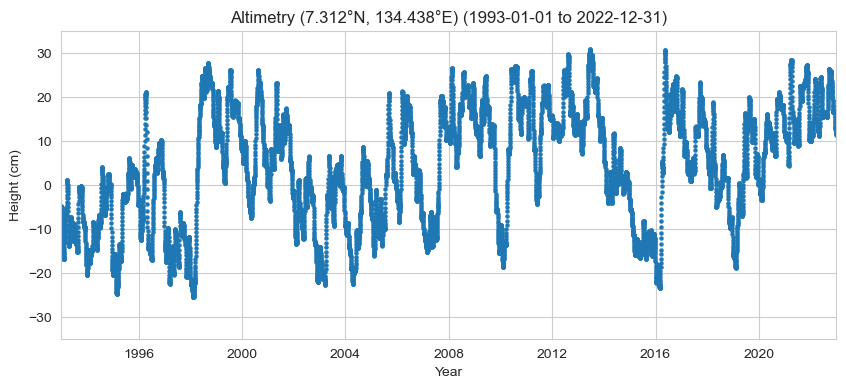

In [15]:
fig, ax = plot_altimetry_scatter(
    sla_nearest=sla_nearest,
    lat_str=lat_str,
    lon_str=lon_str,
    start_date_str=start_date_str,
    end_date_str=end_date_str,
    start_date=start_date,
    end_date=end_date,
)


### Calculate change
Now we have all of our data sources, we'll calculate the absolute and relative sea level change (magnitude in cm) at this location for the Period of Record (1993-2022).

We use the shared trend-calculation utilities to estimate sea level change magnitude.


In [16]:
# Legacy implementation removed to avoid confusion.
# The maintained implementation of `process_trend_with_nan` is defined in the next cell.


Now we'll run that function for every grid point in our dataset, and make special variables for our proxy tide gauge location.


In [17]:
trend_mag_cmems, trend_line_cmems, trend_rate_cmems, p_value_cmems, trend_err_cmems = process_trend_with_nan(sla)

trend_mag_asl, trend_line_asl, trend_rate_asl, p_value_asl,trend_err_asl = process_trend_with_nan(sla_nearest)


Calculate the weighted mean for the region of interest. (Probably not necessary for this application ???)


In [18]:
# calculate the area weights as cosine of latitude
# For a rectangular grid, this is equivalent to multiplying by the grid cell area
weights = np.cos(np.deg2rad(sla.latitude))
weights.name = "weights"

# apply weights to the trend data
trend_mag_weighted = trend_mag_cmems.weighted(weights)

# calculate the regional mean
trend_mag_regional = trend_mag_weighted.mean(dim=('latitude', 'longitude'))

# prepare the output string
output = (
    'The regional magnitude of sea level change is {:.2f} cm for the time '
    'period bounded by {} and {}.'
).format(100*trend_mag_regional.values, start_date_str, end_date_str)

print(output)


The regional magnitude of sea level change is 15.33 cm for the time period bounded by 1993-01-01 and 2022-12-31.


### Plot a map
Plot the Results (in a map that includes the EEZ) – MAP


In [19]:
# Map helper functions were moved to ../../functions/sea_level.py.


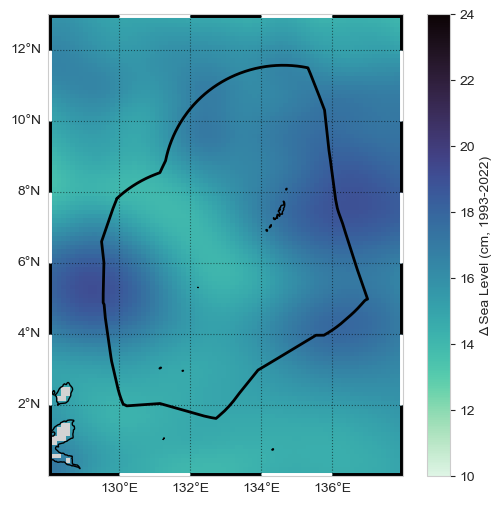

In [20]:
import warnings
warnings.filterwarnings('ignore', category=RuntimeWarning)

fig, ax = plot_magnitude_map_background(
    trend_mag_cmems=trend_mag_cmems,
    site_eez=site_eez,
    vmin=10,
    vmax=24,
    xlims=[128, 138],
    ylims=[0, 13],
)
fig.savefig(site_output_dir / build_output_filename('F10_SeaLevel_map', site_name, site_lon, site_lat), dpi=300, bbox_inches='tight')


(ASLtimeseries)=
### Plot time series
Now we'll plot a time series that includes a trend line, the Absolute Sea Level Change (magnitude in cm) within area/s in proximity to the Tide Station/s


In [21]:
trend_mag_asl.values


array(0.17336469)

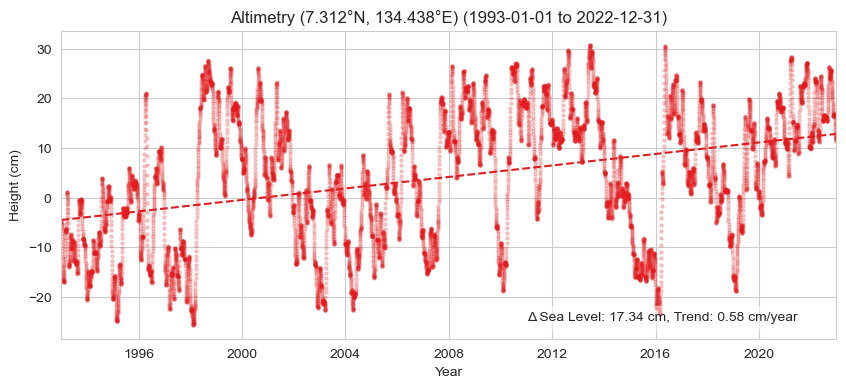

In [22]:
fig, ax = plot_altimetry_trend_timeseries(
    sla_nearest=sla_nearest,
    trend_line_asl=trend_line_asl,
    trend_mag_asl=trend_mag_asl,
    trend_rate_asl=trend_rate_asl,
    lat_str=lat_str,
    lon_str=lon_str,
    start_date_str=start_date_str,
    end_date_str=end_date_str,
    start_date=start_date,
    end_date=end_date,
)


## Retrieve the Tide Station Data 


### Plot the hourly time series
For a quick glance at the data


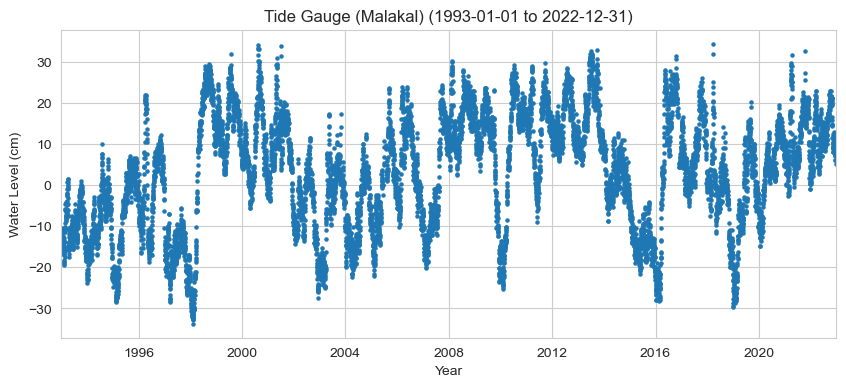

In [23]:
fig, ax = plot_tide_gauge_scatter(
    rsl_daily=rsl_daily,
    station_name=station_name,
    start_date_str=start_date_str,
    end_date_str=end_date_str,
    start_date=start_date,
    end_date=end_date,
)


### Calculate rate and magnitude of change
Calculate values for both the Trend (rate of change) and Magnitude of Change


In [24]:
# calculate the rate of change for the tide gauge
trend_mag_rsl, trend_line_rsl, trend_rate_rsl, p_value_rsl, trend_err_rsl = process_trend_with_nan(rsl_daily.sel(time=slice(start_date, end_date)))

print(f'The trend magnitude for the tide gauge is {100*trend_mag_rsl:.2f} cm.')
print(f'The trend rate for the tide gauge is {100*trend_rate_rsl:.2f} cm/year.')


The trend magnitude for the tide gauge is 12.17 cm.
The trend rate for the tide gauge is 0.41 cm/year.


(RSLtimeseries)=
### Plot time series
Now we'll combine our daily relative sea level time series, the monthly mean, and a trend line into the same plot. We will label it with the Relative Sea Level Sea Level Change (magnitude in cm) and rate of change (cm/yr) at the Tide Station. The "zero" line is referenced to the [1993,2012] period, following the altimetry. 


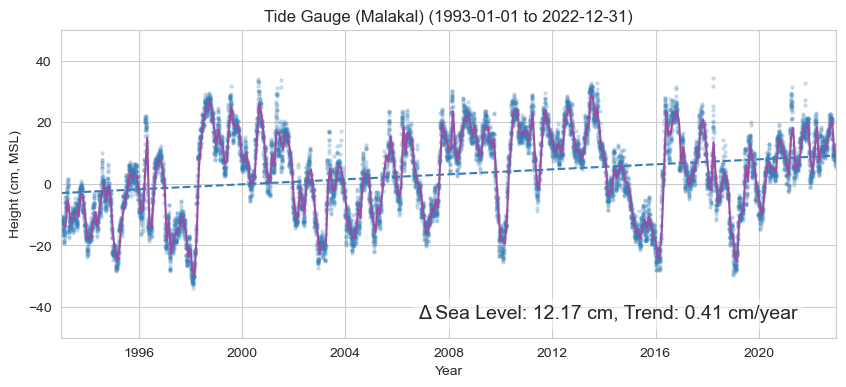

In [25]:
# make an rsl monthly mean for plotting
rsl_monthly = rsl_daily.resample(time='1ME').mean().squeeze()

fig, ax = plot_tide_gauge_trend_timeseries(
    rsl_daily=rsl_daily,
    rsl_monthly=rsl_monthly,
    trend_line_rsl=trend_line_rsl,
    trend_mag_rsl=trend_mag_rsl,
    trend_rate_rsl=trend_rate_rsl,
    station_name=station_name,
    start_date_str=start_date_str,
    end_date_str=end_date_str,
    start_date=start_date,
    end_date=end_date,
)


## Combining both sources


### Create a Table 
That compares the results of the [absolute](ASLtimeseries)  and [relative](RSLtimeseries) time series.


In [26]:
SL_magnitude_results, sl_glue_values = build_sl_magnitude_results(
    trend_rate_asl=trend_rate_asl,
    trend_rate_rsl=trend_rate_rsl,
    trend_mag_asl=trend_mag_asl,
    trend_mag_rsl=trend_mag_rsl,
    sla_nearest_lat=sla_nearest_lat,
    sla_nearest_lon=sla_nearest_lon,
    rsl_lat=rsl['lat'].values[0],
    rsl_lon=rsl['lon'].values[0],
    start_date_str=start_date_str,
    end_date_str=end_date_str,
)

save_table_to_csv(
    SL_magnitude_results,
    site_output_dir,
    build_output_filename('SL_magnitude_results', site_name, site_lon, site_lat, ext='csv'),
    index=True,
)
SL_magnitude_results


,Trend (mm/yr),Trend (in/yr),Δ Sea Level (cm),Δ Sea Level (in),Latitude,Longitude,Time_Period,Data_Source
Altimetry,5.779614,0.227544,17.336469,6.825385,7.3125,134.4375,1993-01-01 to 2022-12-31,CMEMS SSH L4 0.125 deg (SLA)
Tide Gauge,4.055963,0.159684,12.165114,4.789418,7.33,134.462997,1993-01-01 to 2022-12-31,UHSLC RQDS


The cell below will save all these variables for printing:


In [27]:
# glue all table values to the notebook (trend rates etc)
for glue_key, glue_value in sl_glue_values.items():
    glue(glue_key, glue_value, display=False)


### Create a Map 
Now we'll combine a both the tide gauge and altimetry sources into a map that includes the absolute change with the addition of an icon depicting the magnitude of relative change at the tide station.


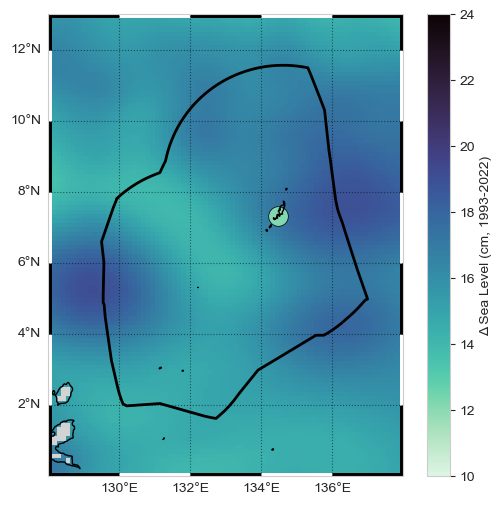

In [28]:
warnings.filterwarnings('ignore', category=RuntimeWarning)
fig, ax = plot_magnitude_map(
    trend_mag_cmems=trend_mag_cmems,
    site_eez=site_eez,
    rsl=rsl,
    trend_mag_rsl=trend_mag_rsl,
    vmin=vmin,
    vmax=vmax,
    xlims=xlims,
    ylims=ylims,
)

glue("mag_fig", fig, display=False)

# save the figure
output_file_path = site_output_dir / build_output_filename('SL_magnitude_map', site_name, site_lon, site_lat)
fig.savefig(output_file_path, dpi=300, bbox_inches='tight')


```{glue:figure} mag_fig
:name: "fig-mag"

Map of absolute and relative sea level change from the altimetry and tide gauge record near {glue:text}`station`, {glue:text}`country` station from {glue:text}`startDateTime` to {glue:text}`endDateTime`.
```


 ### Create a Time series plot 
 Finally we will combine both tide gauge and altimetry sources into a time series plot that includes both [Absolute](ASLtimeseries)  and [Relative](RSLtimeseries) Time Series.


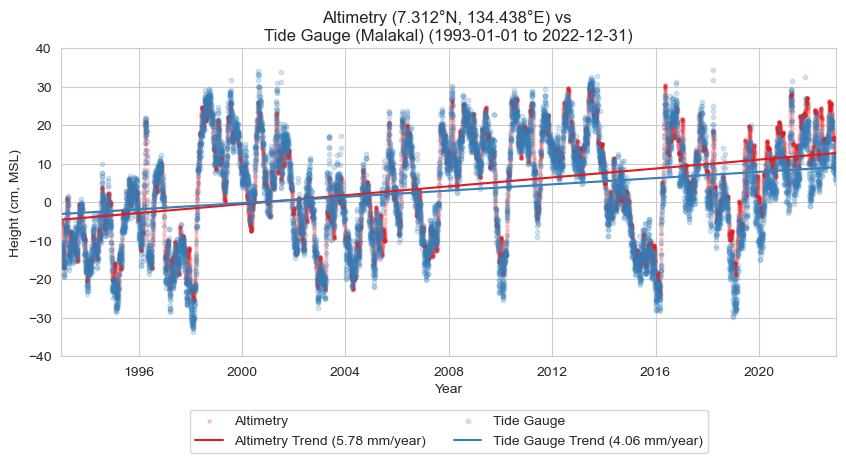

In [29]:
fig, ax = plot_combined_trends(
    sla_nearest=sla_nearest,
    trend_line_asl=trend_line_asl,
    trend_rate_asl=trend_rate_asl,
    rsl_daily=rsl_daily,
    trend_line_rsl=trend_line_rsl,
    trend_rate_rsl=trend_rate_rsl,
    lat_str=lat_str,
    lon_str=lon_str,
    station_name=station_name,
    start_date_str=start_date_str,
    end_date_str=end_date_str,
    start_date=start_date,
    end_date=end_date,
)

glue("trend_fig", fig, display=False)

# save the figure
output_file_path = site_output_dir / build_output_filename('SL_magnitude_timeseries', site_name, site_lon, site_lat)
fig.savefig(output_file_path, dpi=300, bbox_inches='tight')

fig.savefig(site_output_dir / build_output_filename('F10_SeaLevel_trends', site_name, site_lon, site_lat), dpi=300, bbox_inches='tight')


```{glue:figure} trend_fig
:name: "trend_fig"

Absolute sea level trend (red) from altimetry, and relative sea level trend (blue) from the tide gauge record at the {glue:text}`station`, {glue:text}`country` station from {glue:text}`startDateTime` to {glue:text}`endDateTime`. Note also that the trends should go through 0 at the same location, but we are using different PORs for both. I need to fix this!!
```


In [30]:
rsl


<xarray.Dataset> Size: 249kB
Dimensions:               (record_id: 1, time: 20771)
Coordinates:
  * time                  (time) datetime64[ns] 166kB 1969-05-19T12:00:00 ......
  * record_id             (record_id) int64 8B 7
Data variables:
    sea_level             (record_id, time) float32 83kB ...
    lat                   (record_id) float32 4B 7.33
    lon                   (record_id) float32 4B 134.5
    station_name          (record_id) <U7 28B 'Malakal'
    station_country       (record_id) <U5 20B 'Palau'
    station_country_code  (record_id) float32 4B ...
    uhslc_id              (record_id) int16 2B ...
    gloss_id              (record_id) float32 4B ...
    ssc_id                (record_id) |S4 4B ...
    last_rq_date          (record_id) datetime64[ns] 8B ...
Attributes:
    title:                  UHSLC Fast Delivery Tide Gauge Data (daily)
    ncei_template_version:  NCEI_NetCDF_TimeSeries_Orthogonal_Template_v2.0
    featureType:            timeSeries
    Conventions:            CF-1.6, ACDD-1.3
    date_created:           2026-05-05T14:26:56Z
    publisher_name:         University of Hawaii Sea Level Center (UHSLC)
    publisher_email:        philiprt@hawaii.edu, markm@soest.hawaii.edu
    publisher_url:          http://uhslc.soest.hawaii.edu
    summary:                The UHSLC assembles and distributes the Fast Deli...
    processing_level:       Fast Delivery (FD) data undergo a level 1 quality...
    acknowledgment:         The UHSLC Fast Delivery database is supported by ...

## ENSO Effects on Sea Level

Next we'll look at the variation of sea level with El Niño and La Niña.


In [31]:
# add nino
p_data = 'https://psl.noaa.gov/data/correlation/oni.data'
oni = download_oni_index(p_data)


In [32]:
# Remove the trend from the tide gauge timeseries
detrended_rsl = rsl_daily - trend_line_rsl

# estimate the seasonal cycle (detrended_rsl is xarray)
seasonal_cycle = detrended_rsl.groupby('time.dayofyear').mean('time')

# Remove the seasonal cycle from the detrended tide gauge timeseries
deseasoned_rsl = detrended_rsl.groupby('time.dayofyear') - seasonal_cycle

# Resample the ONI index to daily frequency and align with the tide gauge timeseries
oni_daily = oni.resample('D').interpolate(method='linear')
oni_daily = oni_daily.reindex(deseasoned_rsl['time'], method='nearest')


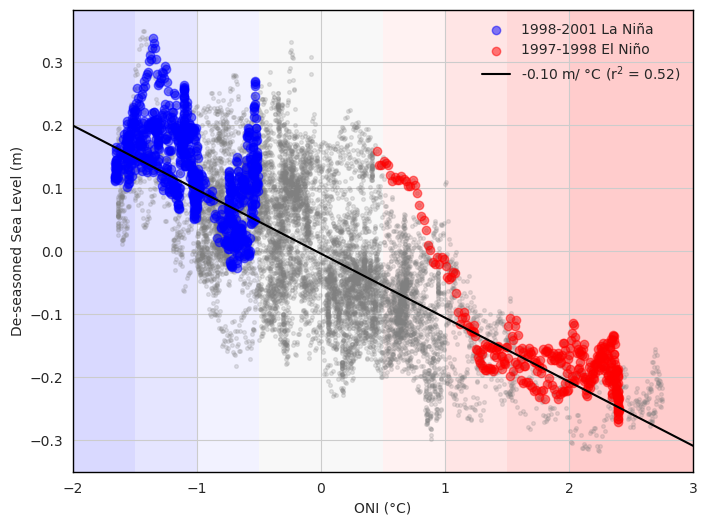

In [33]:
fig, ax, slope, intercept, r_value, p_value, std_err, nina_1998, nino_1997 = plot_enso_scatter(
    oni_daily=oni_daily,
    deseasoned_rsl=deseasoned_rsl,
)

# save the figure
output_file_path = site_output_dir / build_output_filename('SL_ONI_scatter', site_name, site_lon, site_lat)
fig.savefig(output_file_path, dpi=300, bbox_inches='tight')


In [34]:
summary_table, styled_df = build_enso_summary_table(
    slope=slope,
    nino_1997=nino_1997,
    nina_1998=nina_1998,
    r_value=r_value,
    p_value=p_value,
)

save_table_to_csv(
    summary_table,
    site_output_dir,
    build_output_filename('ENSO_SL_influence_summary', site_name, site_lon, site_lat, ext='csv'),
    index=False,
)

summary_metrics = {
    'site_name': site_name,
    'station': station,
    'country': country,
    'period_start': start_date_str,
    'period_end': end_date_str,
    'altimetry_trend_mmyr': float(1000 * trend_rate_asl.values),
    'tide_gauge_trend_mmyr': float(1000 * trend_rate_rsl.values),
    'altimetry_delta_cm': float(100 * trend_mag_asl.values),
    'tide_gauge_delta_cm': float(100 * trend_mag_rsl.values),
    'oni_slope_m_per_degC': float(slope),
    'oni_r': float(r_value),
    'oni_p_value': float(p_value),
}
save_dict_json(
    summary_metrics,
    site_output_dir,
    build_output_filename('SL_trend_summary_metrics', site_name, site_lon, site_lat, ext='json'),
)
styled_df


,Description,Value
0,Slope of Correlation Line,-0.10 m/°C
1,El Niño 1997-1998 Min Sea Level,-27.16 cm
2,El Niño 1997-1998 Median Sea Level,-17.61 cm
3,La Niña 1998-2000 Max Sea Level,33.81 cm
4,La Niña 1998-2000 Median Sea Level,13.63 cm
5,Correlation Coefficient (r),-0.72
6,p-value,0.00
7,Source: NOAA / University of Hawaii Sea Level Center,
8,Notes: Sea level data has been deseasoned and detrended.,
